In [1]:
print("Run Python")

Run Python


In [24]:
import seaborn as sns

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

import pennylane as qml
from pennylane import numpy as pnp

In [14]:
iris = load_iris()

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df["species"] = iris.target

In [15]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [17]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
sepal length (cm),150.0,5.843333,0.828066,4.3,5.1,5.80,6.4,7.9
sepal width (cm),150.0,3.057333,0.435866,2.0,2.8,3.00,3.3,4.4
petal length (cm),150.0,3.758000,1.765298,1.0,1.6,4.35,5.1,6.9
petal width (cm),150.0,1.199333,0.762238,0.1,0.3,1.30,1.8,2.5
species,150.0,1.000000,0.819232,0.0,0.0,1.00,2.0,2.0


In [18]:
df["species"].value_counts()

species
0    50
1    50
2    50
Name: count, dtype: int64

In [21]:
species_names = iris.target_names

df["species_name"] = df["species"].map({
    0: species_names[0],
    1: species_names[1],
    2: species_names[2]
})

df.head(100
    )

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa
...,...,...,...,...,...,...
95,5.7,3.0,4.2,1.2,1,versicolor
96,5.7,2.9,4.2,1.3,1,versicolor
97,6.2,2.9,4.3,1.3,1,versicolor
98,5.1,2.5,3.0,1.1,1,versicolor


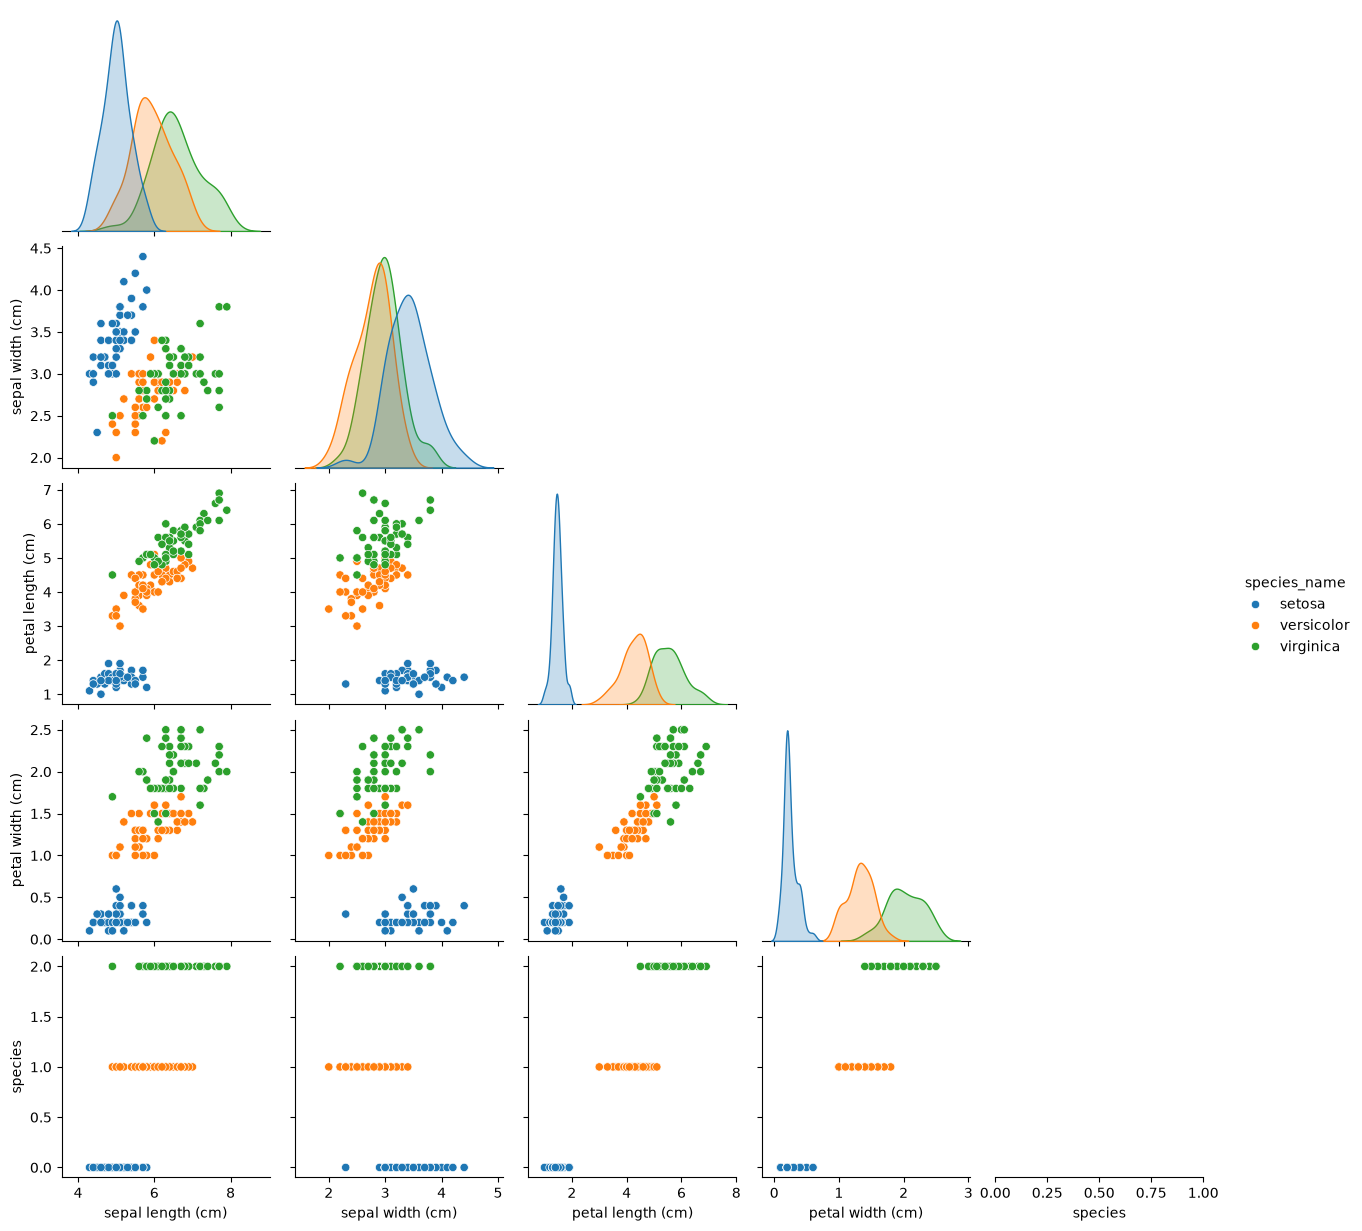

In [25]:
sns.pairplot(
    df,
    hue="species_name",
    corner=True
)

plt.show()

In [26]:
X = df[iris.feature_names].values
y = df["species"].values

In [27]:
print(X.shape)
print(y.shape)

(150, 4)
(150,)


In [28]:
scaler = MinMaxScaler(
    feature_range=(0, np.pi)
)

X_scaled = scaler.fit_transform(X)

In [30]:
print(X_scaled
    )

[[0.6981317  1.96349541 0.21298933 0.13089969]
 [0.52359878 1.30899694 0.21298933 0.13089969]
 [0.34906585 1.57079633 0.159742   0.13089969]
 [0.26179939 1.43989663 0.26623667 0.13089969]
 [0.61086524 2.0943951  0.21298933 0.13089969]
 [0.95993109 2.48709418 0.37273133 0.39269908]
 [0.26179939 1.83259571 0.21298933 0.26179939]
 [0.61086524 1.83259571 0.26623667 0.13089969]
 [0.08726646 1.17809725 0.21298933 0.13089969]
 [0.52359878 1.43989663 0.26623667 0.        ]
 [0.95993109 2.2252948  0.26623667 0.13089969]
 [0.43633231 1.83259571 0.319484   0.13089969]
 [0.43633231 1.30899694 0.21298933 0.        ]
 [0.         1.30899694 0.05324733 0.        ]
 [1.30899694 2.61799388 0.10649467 0.13089969]
 [1.22173048 3.14159265 0.26623667 0.39269908]
 [0.95993109 2.48709418 0.159742   0.39269908]
 [0.6981317  1.96349541 0.21298933 0.26179939]
 [1.22173048 2.35619449 0.37273133 0.26179939]
 [0.6981317  2.35619449 0.26623667 0.26179939]
 [0.95993109 1.83259571 0.37273133 0.13089969]
 [0.6981317  

In [31]:
print(X_scaled.min())
print(X_scaled.max())

0.0
3.1415926535897936


In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [33]:
print(X_train.shape)
print(X_test.shape)

(120, 4)
(30, 4)


In [34]:
# Number of features = Number of qubits
n_qubits = 4

# Create a local quantum simulator
dev = qml.device(
    "default.qubit",
    wires=n_qubits
)

print(dev)

<default.qubit device (wires=4) at 0x17de8acdfd0>


In [35]:
def angle_encoding(x):
    """
    Encodes one classical data sample into
    the quantum circuit using RY rotations.
    """

    for i in range(n_qubits):
        qml.RY(x[i], wires=i)
    

In [36]:
@qml.qnode(dev)
def quantum_circuit(x):
    
    # Encode classical data
    angle_encoding(x)
    
    # Measure each qubit
    return [
        qml.expval(qml.PauliZ(i))
        for i in range(n_qubits)
    ]

In [37]:
sample = X_train[0]

output = quantum_circuit(sample)

print("Encoded sample:")
print(sample)

print("\nQuantum output:")
print(output)

Encoded sample:
[0.08726646 1.17809725 0.21298933 0.13089969]

Quantum output:
[np.float64(0.9961946980917452), np.float64(0.38268343236509), np.float64(0.9774033898178665), np.float64(0.9914448613738102)]


In [38]:
print(qml.draw(quantum_circuit)(X_train[0]))

0: ──RY(0.09)─┤  <Z>
1: ──RY(1.18)─┤  <Z>
2: ──RY(0.21)─┤  <Z>
3: ──RY(0.13)─┤  <Z>


In [39]:
# Number of trainable layers
n_layers = 2

In [40]:
# Random initialization of trainable parameters
weights = pnp.random.uniform(
    low=-0.1,
    high=0.1,
    size=(n_layers, n_qubits),
    requires_grad=True
)

weights

tensor([[-0.07355393, -0.07899254, -0.06937029, -0.09917939],
        [ 0.03990435,  0.04197903,  0.05348028, -0.02387269]], requires_grad=True)

In [41]:
@qml.qnode(dev)
def variational_circuit(x, weights):

    # --------------------------
    # 1. Encode classical data
    # --------------------------
    angle_encoding(x)

    # --------------------------
    # 2. Trainable layers
    # --------------------------
    for layer in range(n_layers):

        # Trainable rotations
        for qubit in range(n_qubits):
            qml.RY(weights[layer, qubit], wires=qubit)

        # Entanglement
        for qubit in range(n_qubits - 1):
            qml.CNOT(wires=[qubit, qubit + 1])

        # Close the ring
        qml.CNOT(wires=[3, 0])

    # --------------------------
    # 3. Measurement
    # --------------------------
    return [qml.expval(qml.PauliZ(i)) for i in range(3)]

In [42]:
print(qml.draw(variational_circuit)(X_train[0], weights))

0: ──RY(0.09)──RY(-0.07)─╭●───────╭X──RY(0.04)──╭●───────╭X─┤  <Z>
1: ──RY(1.18)──RY(-0.08)─╰X─╭●────│───RY(0.04)──╰X─╭●────│──┤  <Z>
2: ──RY(0.21)──RY(-0.07)────╰X─╭●─│───RY(0.05)─────╰X─╭●─│──┤  <Z>
3: ──RY(0.13)──RY(-0.10)───────╰X─╰●──RY(-0.02)───────╰X─╰●─┤     


In [58]:
# take one sample from training set
x_sample = X_train[0]

# run quantum circuit
output = variational_circuit(x_sample, weights)

# convert to clean numpy-like values
output = pnp.array(output)

print("Quantum Circuit Output:")
print(output)

Quantum Circuit Output:
[0.44761579 0.98745881 0.44693894]


In [44]:
def softmax(x):
    exp_x = pnp.exp(x - pnp.max(x))
    return exp_x / pnp.sum(exp_x)

In [45]:
scores = variational_circuit(
    X_train[0],
    weights
)

probabilities = softmax(scores)

print(probabilities)

[0.26917459 0.46183294 0.26899246]


In [46]:
def predict(x, weights):

    scores = variational_circuit(x, weights)

    probs = softmax(scores)

    return int(pnp.argmax(probs))

In [47]:
prediction = predict(
    X_train[0],
    weights
)

print("Prediction:", prediction)
print("True Label:", y_train[0])

Prediction: 1
True Label: 0


In [48]:
def one_hot(label, num_classes=3):
    vec = np.zeros(num_classes)
    vec[label] = 1
    return vec

In [49]:
print(one_hot(0))
print(one_hot(1))
print(one_hot(2))

[1. 0. 0.]
[0. 1. 0.]
[0. 0. 1.]


In [50]:
def softmax(x):
    exp = pnp.exp(x - pnp.max(x))
    return exp / pnp.sum(exp)

In [51]:
scores = pnp.array([2.0, 0.5, -1.0])

print(softmax(scores))

[0.78559703 0.17529039 0.03911257]


In [52]:
def forward(x, weights):
    logits = pnp.array(
        variational_circuit(x, weights)
    )

    probs = softmax(logits)

    return probs

In [53]:
def cross_entropy(y_true, y_pred):

    eps = 1e-10

    return -pnp.sum(
        y_true * pnp.log(y_pred + eps)
    )

In [59]:
def cost(weights):

    losses = []

    for x, label in zip(X_train, y_train):

        probs = forward(x, weights)

        target = one_hot(label)

        losses.append(
            cross_entropy(target, probs)
        )

    return pnp.stack(losses).mean()

In [60]:
optimizer = qml.AdamOptimizer(
    stepsize=0.05
)

In [62]:
epochs = 50

loss_history = []

for epoch in range(epochs):

    weights = optimizer.step(
        cost,
        weights
    )

    current_loss = cost(weights)

    loss_history.append(current_loss)

    if epoch % 5 == 0:

        print(
            f"Epoch {epoch:02d} | Loss = {current_loss:.4f}"
        )

Epoch 00 | Loss = 0.9872
Epoch 05 | Loss = 0.9547
Epoch 10 | Loss = 0.9153
Epoch 15 | Loss = 0.8764
Epoch 20 | Loss = 0.8374
Epoch 25 | Loss = 0.7931
Epoch 30 | Loss = 0.7515
Epoch 35 | Loss = 0.7218
Epoch 40 | Loss = 0.7078
Epoch 45 | Loss = 0.7072
